# Mutual Fund Performance Analytics

This notebook contains the complete performance analysis for **40 mutual fund schemes**.
The analysis is performed using daily Net Asset Value (NAV) data and stock market benchmark indices stored in the SQLite database `bluestock_mf.db`.

### Analysis Outline:
1. **Compute Daily Returns** and validate their distribution.
2. **Compute CAGR** (1-Year, 3-Year, and Max-Available ~4.4 Years).
3. **Sharpe Ratio** (annualized, using $R_f = 6.5\%$).
4. **Sortino Ratio** (annualized, using downside standard deviation of negative returns).
5. **Alpha and Beta** coefficients from OLS regression against the Nifty 100 index.
6. **Maximum Drawdown** and the worst drawdown date range (peak to trough).
7. **Composite Fund Scorecard (0–100)** ranking the 40 funds.
8. **Benchmark Comparison Chart** and **Tracking Error** for the top 5 scorecard-ranked funds against Nifty 50 and Nifty 100.

---



## Setup and Data Ingestion
We connect to the SQLite database `bluestock_mf.db` and load:
* `dim_fund`: Fund master details (expense ratio, scheme name, etc.)
* `fact_nav`: Historical NAV data
* `fact_benchmark_indices`: Closing values of market benchmarks



In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import os

# Set matplotlib inline and style
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Connect to the SQLite database
db_path = r"../Day 2 - Cleaned data + SQLite DB loaded/bluestock_mf.db"
conn = sqlite3.connect(db_path)

# Load tables into pandas DataFrames
df_funds = pd.read_sql_query("SELECT amfi_code, fund_house, scheme_name, category, expense_ratio_pct FROM dim_fund;", conn)
df_nav_raw = pd.read_sql_query("SELECT amfi_code, date, nav FROM fact_nav;", conn)
df_bench_raw = pd.read_sql_query("SELECT date, index_name, close_value FROM fact_benchmark_indices;", conn)

# Align dates to trading days only (dates present in benchmark table)
trading_dates = sorted(df_bench_raw['date'].unique())
df_nav = df_nav_raw[df_nav_raw['date'].isin(trading_dates)].copy()

# Sort data and clean types
df_nav = df_nav.sort_values(['amfi_code', 'date'])
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav.set_index('date', inplace=True)

df_bench = df_bench_raw.copy()
df_bench['date'] = pd.to_datetime(df_bench['date'])
df_bench = df_bench.sort_values(['index_name', 'date'])

print(f"Loaded {len(df_funds)} funds, {len(df_nav)} NAV records, and {len(df_bench)} benchmark records.")
conn.close()


Loaded 40 funds, 46000 NAV records, and 8050 benchmark records.


## Task 1: Compute Daily Returns
We compute the daily returns for each fund using the formula:
$$R_t = rac{	ext{NAV}_t}{	ext{NAV}_{t-1}} - 1$$

We group the data by fund and calculate the returns. To validate that the distribution is reasonable, we will print descriptive statistics, skewness, and kurtosis, and plot the distribution.



Aggregated Daily Returns Summary Statistics:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64
Returns Skewness: 0.0427
Returns Kurtosis: 1.3673


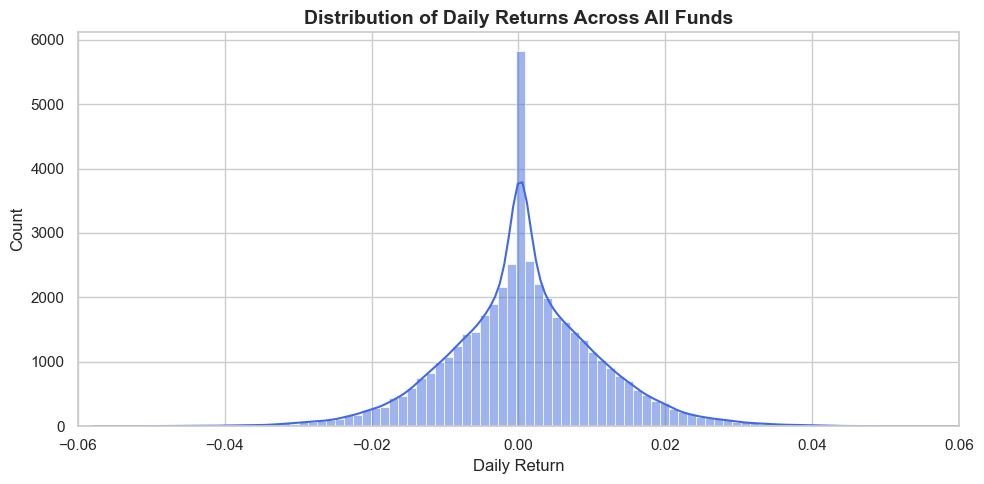

In [2]:
# Compute daily returns
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Statistics for validation
returns_desc = df_nav['daily_return'].describe()
print("Aggregated Daily Returns Summary Statistics:")
print(returns_desc)
print(f"Returns Skewness: {df_nav['daily_return'].skew():.4f}")
print(f"Returns Kurtosis: {df_nav['daily_return'].kurtosis():.4f}")

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_nav['daily_return'].dropna(), kde=True, bins=100, color='royalblue')
plt.title('Distribution of Daily Returns Across All Funds', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xlim(-0.06, 0.06)
plt.tight_layout()
plt.show()


## Task 2: Compute CAGR for 1yr, 3yr, and Max-Available
We calculate the Compounded Annual Growth Rate (CAGR) using the formula:
$$	ext{CAGR} = \left(rac{	ext{NAV}_{	ext{end}}}{	ext{NAV}_{	ext{start}}}ight)^{rac{1}{n}} - 1$$

* **1-Year CAGR**: $n=1$, start date `2025-05-29`, end date `2026-05-29`.
* **3-Year CAGR**: $n=3$, start date `2023-05-29`, end date `2026-05-29`.
* **Max-Available CAGR**: $n=4.40$ years, start date `2022-01-03`, end date `2026-05-29`.



In [3]:
# Define date milestones
end_date = pd.to_datetime('2026-05-29')
start_1yr = pd.to_datetime('2025-05-29')
start_3yr = pd.to_datetime('2023-05-29')
start_max = pd.to_datetime('2022-01-03')

n_years_max = (end_date - start_max).days / 365.25 # 4.4025 years

cagr_data = []

for amfi in df_funds['amfi_code']:
    fund_nav = df_nav[df_nav['amfi_code'] == amfi]['nav'].sort_index()
    
    nav_end = fund_nav.asof(end_date)
    nav_1yr = fund_nav.asof(start_1yr)
    nav_3yr = fund_nav.asof(start_3yr)
    nav_max = fund_nav.asof(start_max)
    
    cagr_1yr = (nav_end / nav_1yr) - 1
    cagr_3yr = (nav_end / nav_3yr) ** (1/3) - 1
    cagr_max = (nav_end / nav_max) ** (1/n_years_max) - 1
    
    cagr_data.append({
        'amfi_code': amfi,
        'return_1yr_cagr': cagr_1yr,
        'return_3yr_cagr': cagr_3yr,
        'return_max_cagr': cagr_max
    })

df_cagr = pd.DataFrame(cagr_data)
df_cagr_display = df_funds[['amfi_code', 'scheme_name']].merge(df_cagr, on='amfi_code')

print("First 5 CAGR records:")
print(df_cagr_display.head().to_string(index=False))


First 5 CAGR records:
 amfi_code                                        scheme_name  return_1yr_cagr  return_3yr_cagr  return_max_cagr
    100016          HDFC Top 100 Fund - Regular Plan - Growth        -0.022243         0.012926         0.026371
    100025       HDFC Short Term Debt Fund - Regular - Growth         0.037050         0.039164         0.044582
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth         0.532324         0.324425         0.301232
    101206      ABSL Frontline Equity Fund - Regular - Growth         0.479241         0.289677         0.235384
    101207             ABSL Small Cap Fund - Regular - Growth        -0.239860        -0.041524         0.079388


## Tasks 3 & 4: Sharpe and Sortino Ratios
* **Sharpe Ratio** measures risk-adjusted performance:
  $$	ext{Sharpe} = rac{	ext{Mean}(R_p) - R_{f,	ext{daily}}}{	ext{Std}(R_p)} 	imes \sqrt{252}$$
* **Sortino Ratio** focuses on downside risk only:
  $$	ext{Sortino} = rac{	ext{Mean}(R_p) - R_{f,	ext{daily}}}{	ext{DownsideStd}(R_p)} 	imes \sqrt{252}$$

We use $R_f = 6.5\%$ (RBI repo rate proxy), which equates to a daily risk-free rate of $R_{f,	ext{daily}} = 6.5\% / 252$.
The downside deviation is calculated using only **negative return days** as specified.



In [4]:
rf_annual = 0.065
rf_daily = rf_annual / 252

ratios_data = []

for amfi in df_funds['amfi_code']:
    fund_returns = df_nav[df_nav['amfi_code'] == amfi]['daily_return'].dropna()
    
    mean_return = fund_returns.mean()
    std_return = fund_returns.std()
    
    # Sharpe Ratio
    sharpe = (mean_return - rf_daily) / std_return * np.sqrt(252)
    
    # Sortino Ratio (downside std: negative returns only)
    downside_returns = fund_returns[fund_returns < 0]
    downside_std = downside_returns.std()
    sortino = (mean_return - rf_daily) / downside_std * np.sqrt(252)
    
    ratios_data.append({
        'amfi_code': amfi,
        'vol_ann_pct': std_return * np.sqrt(252) * 100,
        'downside_vol_ann_pct': downside_std * np.sqrt(252) * 100,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino
    })

df_ratios = pd.DataFrame(ratios_data)
df_ratios_display = df_funds[['amfi_code', 'scheme_name']].merge(df_ratios, on='amfi_code')

# Rank funds by Sharpe ratio
df_sharpe_rank = df_ratios_display.sort_values('sharpe_ratio', ascending=False).copy()
df_sharpe_rank['sharpe_rank'] = range(1, 41)

print("Top 10 Funds ranked by Sharpe Ratio:")
print(df_sharpe_rank[['sharpe_rank', 'scheme_name', 'vol_ann_pct', 'sharpe_ratio', 'sortino_ratio']].head(10).to_string(index=False))


Top 10 Funds ranked by Sharpe Ratio:
 sharpe_rank                                        scheme_name  vol_ann_pct  sharpe_ratio  sortino_ratio
           1      Mirae Asset Large Cap Fund - Regular - Growth    14.193707      1.448291       2.385644
           2             Kotak Flexicap Fund - Regular - Growth    15.886987      1.306744       2.364320
           3      Mirae Asset Tax Saver Fund - Regular - Growth    17.674007      1.234930       2.146914
           4          SBI Bluechip Fund - Regular Plan - Growth    13.741434      1.208267       2.140267
           5           ICICI Pru Midcap Fund - Regular - Growth    19.290949      1.180101       2.029353
           6                 DSP Midcap Fund - Regular - Growth    17.746159      1.132122       1.875101
           7 HDFC Mid-Cap Opportunities Fund - Regular - Growth    18.936711      1.093699       1.829134
           8     Nippon India Large Cap Fund - Regular - Growth    14.148352      1.081659       1.850133
         

## Task 5: Alpha and Beta OLS Regression
We perform an Ordinary Least Squares (OLS) regression of the daily returns of each fund against the daily returns of the **Nifty 100** index using `scipy.stats.linregress`.
$$	ext{Alpha (annualized)} = 	ext{intercept} 	imes 252$$
$$	ext{Beta} = 	ext{slope}$$



In [5]:
# Get Nifty 100 returns
df_nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'].copy()
df_nifty100.set_index('date', inplace=True)
df_nifty100['daily_return'] = df_nifty100['close_value'].pct_change()
nifty100_returns = df_nifty100['daily_return'].dropna()

alpha_beta_data = []

for amfi in df_funds['amfi_code']:
    fund_returns = df_nav[df_nav['amfi_code'] == amfi]['daily_return'].dropna()
    
    # Align dates
    aligned = pd.concat([fund_returns, nifty100_returns], axis=1, join='inner')
    aligned.columns = ['fund', 'benchmark']
    
    # Run OLS
    beta, intercept, r_val, p_val, std_err = linregress(aligned['benchmark'], aligned['fund'])
    alpha_ann = intercept * 252
    
    alpha_beta_data.append({
        'amfi_code': amfi,
        'alpha': alpha_ann,
        'beta': beta,
        'r_squared': r_val ** 2
    })

df_alpha_beta = pd.DataFrame(alpha_beta_data)
df_alpha_beta_display = df_funds[['amfi_code', 'scheme_name']].merge(df_alpha_beta, on='amfi_code')

# Save to CSV
df_alpha_beta_display.to_csv('alpha_beta.csv', index=False)
print("Saved alpha_beta.csv.")
print("\nFirst 10 alpha/beta records:")
print(df_alpha_beta_display.head(10).to_string(index=False))


Saved alpha_beta.csv.

First 10 alpha/beta records:
 amfi_code                                        scheme_name    alpha      beta  r_squared
    100016          HDFC Top 100 Fund - Regular Plan - Growth 0.037476 -0.058268   0.002665
    100025       HDFC Short Term Debt Fund - Regular - Growth 0.042818  0.001158   0.000015
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.271954  0.005104   0.000012
    101206      ABSL Frontline Equity Fund - Regular - Growth 0.213998  0.021086   0.000348
    101207             ABSL Small Cap Fund - Regular - Growth 0.108971 -0.065289   0.001064
    101208                ABSL Liquid Fund - Regular - Growth 0.060861  0.000267   0.000046
    102885         UTI Nifty 50 Index Fund - Regular - Growth 0.170488 -0.019487   0.000383
    102886                UTI Mid Cap Fund - Regular - Growth 0.028969 -0.042125   0.000896
    102887              UTI Flexi Cap Fund - Regular - Growth 0.162113  0.016683   0.000186
    118632     Nippon India 

## Task 6: Maximum Drawdown
Maximum drawdown is the maximum observed loss from a peak to a trough of a portfolio's value:
$$	ext{Drawdown}_t = rac{	ext{NAV}_t}{	ext{RunningMax}_t} - 1$$
$$	ext{MaxDrawdown} = \min_t(	ext{Drawdown}_t)$$

For each fund, we find the maximum drawdown percentage and the exact date range (peak date to trough date) of this worst drawdown period.



In [6]:
drawdown_data = []

for amfi in df_funds['amfi_code']:
    fund_nav = df_nav[df_nav['amfi_code'] == amfi]['nav'].sort_index()
    
    running_max = fund_nav.cummax()
    drawdowns = fund_nav / running_max - 1
    max_dd = drawdowns.min()
    
    # Locate peak and trough
    trough_date = drawdowns.idxmin()
    peak_date = fund_nav.loc[:trough_date].idxmax()
    
    drawdown_data.append({
        'amfi_code': amfi,
        'max_drawdown': max_dd,
        'worst_dd_peak_date': peak_date.strftime('%Y-%m-%d'),
        'worst_dd_trough_date': trough_date.strftime('%Y-%m-%d')
    })

df_drawdowns = pd.DataFrame(drawdown_data)
df_drawdowns_display = df_funds[['amfi_code', 'scheme_name']].merge(df_drawdowns, on='amfi_code')

# Format drawdown for printing
df_drawdowns_print = df_drawdowns_display.copy()
df_drawdowns_print['max_drawdown_pct'] = df_drawdowns_print['max_drawdown'] * 100

print("First 10 Maximum Drawdown records:")
print(df_drawdowns_print[['scheme_name', 'max_drawdown_pct', 'worst_dd_peak_date', 'worst_dd_trough_date']].head(10).to_string(index=False))


First 10 Maximum Drawdown records:
                                       scheme_name  max_drawdown_pct worst_dd_peak_date worst_dd_trough_date
         HDFC Top 100 Fund - Regular Plan - Growth        -24.734441         2022-03-30           2022-09-15
      HDFC Short Term Debt Fund - Regular - Growth         -4.308264         2023-05-23           2023-07-28
HDFC Mid-Cap Opportunities Fund - Regular - Growth        -16.217209         2022-03-11           2022-05-12
     ABSL Frontline Equity Fund - Regular - Growth        -11.291596         2023-04-24           2023-07-05
            ABSL Small Cap Fund - Regular - Growth        -35.446916         2024-11-21           2026-05-11
               ABSL Liquid Fund - Regular - Growth         -0.162250         2023-09-05           2023-09-12
        UTI Nifty 50 Index Fund - Regular - Growth        -10.859862         2022-02-03           2022-03-29
               UTI Mid Cap Fund - Regular - Growth        -28.001124         2025-01-07      

## Task 7: Fund Scorecard (0–100)
We build a composite score using the weighted percentile ranks of 5 key metrics:
* **3-Year Return Rank**: $30\%$ weight
* **Sharpe Rank**: $25\%$ weight
* **Alpha Rank**: $20\%$ weight
* **Expense Ratio Rank (inverse)**: $15\%$ weight (lower is better)
* **Max Drawdown Rank (inverse)**: $10\%$ weight (less negative drawdown is better)

The ranks are computed as percentiles (0 to 100) across all 40 funds. We then calculate the final score and rank all 40 funds.



In [7]:
# Combine all computed metrics
df_composite = df_funds.merge(df_cagr[['amfi_code', 'return_3yr_cagr']], on='amfi_code')
df_composite = df_composite.merge(df_ratios[['amfi_code', 'sharpe_ratio']], on='amfi_code')
df_composite = df_composite.merge(df_alpha_beta[['amfi_code', 'alpha']], on='amfi_code')
df_composite = df_composite.merge(df_drawdowns[['amfi_code', 'max_drawdown']], on='amfi_code')

# Compute percentile ranks (0 to 100)
df_composite['rank_3yr'] = df_composite['return_3yr_cagr'].rank(pct=True) * 100
df_composite['rank_sharpe'] = df_composite['sharpe_ratio'].rank(pct=True) * 100
df_composite['rank_alpha'] = df_composite['alpha'].rank(pct=True) * 100
df_composite['rank_expense_inv'] = (-df_composite['expense_ratio_pct']).rank(pct=True) * 100
df_composite['rank_max_dd_inv'] = df_composite['max_drawdown'].rank(pct=True) * 100

# Compute composite score
df_composite['composite_score'] = (
    0.30 * df_composite['rank_3yr'] +
    0.25 * df_composite['rank_sharpe'] +
    0.20 * df_composite['rank_alpha'] +
    0.15 * df_composite['rank_expense_inv'] +
    0.10 * df_composite['rank_max_dd_inv']
)

# Standard rank (1 to 40)
df_composite['rank'] = df_composite['composite_score'].rank(ascending=False, method='min').astype(int)

# Sort by scorecard rank
df_scorecard = df_composite.sort_values('composite_score', ascending=False).copy()

# Save to CSV
scorecard_cols = [
    'amfi_code', 'scheme_name', 'fund_house', 'category', 
    'return_3yr_cagr', 'sharpe_ratio', 'alpha', 
    'expense_ratio_pct', 'max_drawdown', 'composite_score', 'rank'
]
df_scorecard[scorecard_cols].to_csv('fund_scorecard.csv', index=False)
print("Saved fund_scorecard.csv.")

print("\nTop 10 Funds in Scorecard:")
print(df_scorecard[['rank', 'scheme_name', 'composite_score', 'return_3yr_cagr', 'sharpe_ratio', 'expense_ratio_pct']].head(10).to_string(index=False))


Saved fund_scorecard.csv.

Top 10 Funds in Scorecard:
 rank                                        scheme_name  composite_score  return_3yr_cagr  sharpe_ratio  expense_ratio_pct
    1      Mirae Asset Large Cap Fund - Regular - Growth          86.2500         0.340009      1.448291               1.46
    2           ICICI Pru Midcap Fund - Regular - Growth          82.2500         0.317775      1.180101               1.36
    3             Kotak Flexicap Fund - Regular - Growth          82.0000         0.295828      1.306744               1.45
    4 HDFC Mid-Cap Opportunities Fund - Regular - Growth          80.7500         0.324425      1.093699               1.38
    5          ICICI Pru Bluechip Fund - Direct - Growth          80.0000         0.324874      1.026524               0.80
    6                Axis Midcap Fund - Regular - Growth          77.0000         0.351118      0.998231               1.38
    7          SBI Bluechip Fund - Regular Plan - Growth          74.8125     

## Task 8: Benchmark Comparison Chart and Tracking Error
We select the **top 5 funds** based on the composite scorecard and plot their cumulative performance (growth of base 100) over the **3-year period** (from `2023-05-29` to `2026-05-29`) against Nifty 50 and Nifty 100.

We also compute the **annualized tracking error** for each of these top 5 funds relative to Nifty 50 and Nifty 100:
$$	ext{Tracking Error} = 	ext{Std}(R_{	ext{fund}} - R_{	ext{benchmark}}) 	imes \sqrt{252}$$



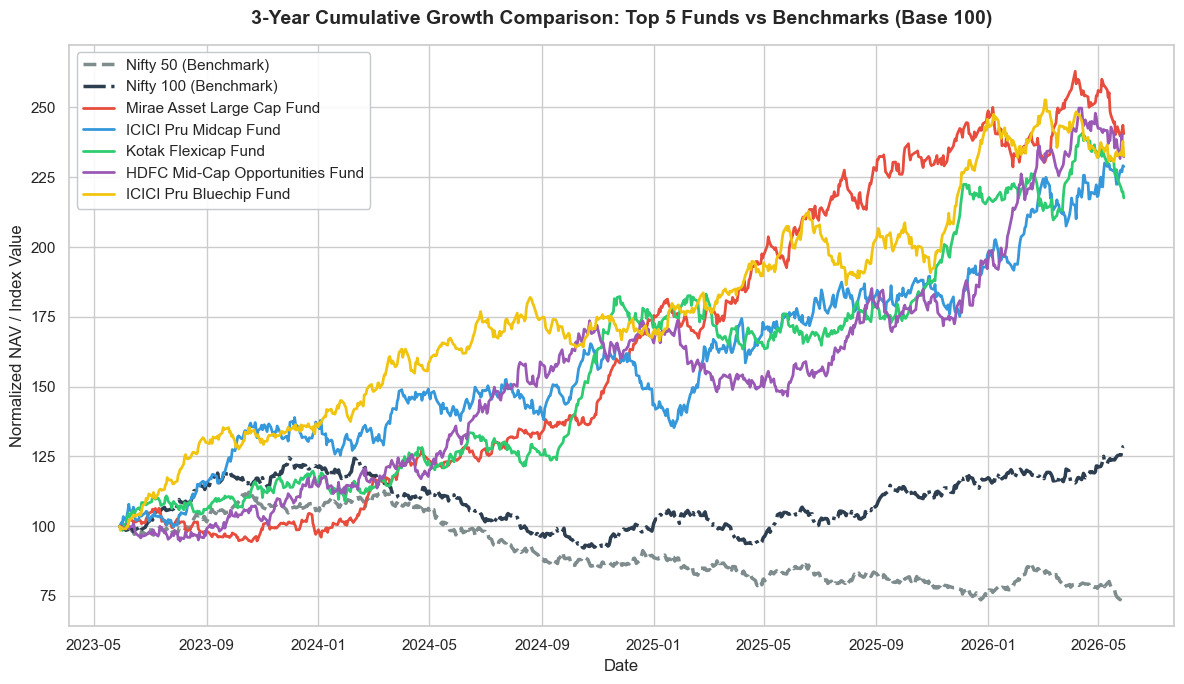

Annualized Tracking Errors (%):
 amfi_code                                        scheme_name  tracking_error_nifty50_pct  tracking_error_nifty100_pct
    148567      Mirae Asset Large Cap Fund - Regular - Growth                   19.186766                    18.797377
    120505           ICICI Pru Midcap Fund - Regular - Growth                   22.844692                    23.266122
    120843             Kotak Flexicap Fund - Regular - Growth                   20.506700                    20.653968
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth                   22.822178                    22.497629
    120504          ICICI Pru Bluechip Fund - Direct - Growth                   18.821141                    18.729904


In [8]:
# Get top 5 funds
top_5_funds = df_scorecard.head(5).copy()
top_5_amfi = list(top_5_funds['amfi_code'])

# Load Nifty 50 and Nifty 100 index values
df_nifty50 = df_bench[df_bench['index_name'] == 'NIFTY50'].copy()
df_nifty50.set_index('date', inplace=True)
df_nifty50_3yr = df_nifty50.loc[start_3yr:end_date].sort_index()

df_nifty100_3yr = df_nifty100.loc[start_3yr:end_date].sort_index()

# Daily returns for tracking error calculation over 3yr
n50_returns_3yr = df_nifty50_3yr['close_value'].pct_change().dropna()
n100_returns_3yr = df_nifty100_3yr['close_value'].pct_change().dropna()

# Normalize growth to start at 100 on start_3yr
nifty50_norm = (df_nifty50_3yr['close_value'] / df_nifty50_3yr['close_value'].iloc[0]) * 100
nifty100_norm = (df_nifty100_3yr['close_value'] / df_nifty100_3yr['close_value'].iloc[0]) * 100

plt.figure(figsize=(12, 7))

# Plot benchmarks
plt.plot(nifty50_norm.index, nifty50_norm, label='Nifty 50 (Benchmark)', color='#7f8c8d', linewidth=2.5, linestyle='--')
plt.plot(nifty100_norm.index, nifty100_norm, label='Nifty 100 (Benchmark)', color='#2c3e50', linewidth=2.5, linestyle='-.')

palette = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f1c40f']
tracking_errors = []

for idx, amfi in enumerate(top_5_amfi):
    fund_name = top_5_funds[top_5_funds['amfi_code'] == amfi]['scheme_name'].values[0]
    # Clean up name for legend
    legend_name = fund_name.split(' - ')[0] if ' - ' in fund_name else fund_name
    legend_name = legend_name.split(' (')[0] if ' (' in legend_name else legend_name
    
    fund_nav_3yr = df_nav[df_nav['amfi_code'] == amfi]['nav'].loc[start_3yr:end_date].sort_index()
    fund_norm = (fund_nav_3yr / fund_nav_3yr.iloc[0]) * 100
    
    # Plot fund
    plt.plot(fund_norm.index, fund_norm, label=legend_name, color=palette[idx], linewidth=2.0)
    
    # Calculate tracking error
    fund_returns_3yr = fund_nav_3yr.pct_change().dropna()
    
    # Align returns for Nifty 50 tracking error
    aligned_n50 = pd.concat([fund_returns_3yr, n50_returns_3yr], axis=1, join='inner')
    te_n50 = (aligned_n50.iloc[:, 0] - aligned_n50.iloc[:, 1]).std() * np.sqrt(252)
    
    # Align returns for Nifty 100 tracking error
    aligned_n100 = pd.concat([fund_returns_3yr, n100_returns_3yr], axis=1, join='inner')
    te_n100 = (aligned_n100.iloc[:, 0] - aligned_n100.iloc[:, 1]).std() * np.sqrt(252)
    
    tracking_errors.append({
        'amfi_code': amfi,
        'scheme_name': fund_name,
        'tracking_error_nifty50_pct': te_n50 * 100,
        'tracking_error_nifty100_pct': te_n100 * 100
    })

plt.title('3-Year Cumulative Growth Comparison: Top 5 Funds vs Benchmarks (Base 100)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized NAV / Index Value', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, edgecolor='#bdc3c7')
plt.tight_layout()

# Save chart PNG
plt.savefig('benchmark_comparison.png', dpi=300)
plt.show()

# Display tracking errors
df_te = pd.DataFrame(tracking_errors)
print("Annualized Tracking Errors (%):")
print(df_te.to_string(index=False))
